## Notebook 05 - Spectrogram Analysis
### Research Question
If RMS Energy is similar, do the spectrograms reveal differences between normal and abnormal recordings?
### Motivation
The previous notebook showed that RMS Energy alone cannot distinguish all anomalies. This notebook investigates whether time-frequency representations reveal hidden structural changes.

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import *
from src.dataset import *
from src.io import *
from src.visualization import *

In [2]:
overlap_df = pd.read_csv("C:/MyProjects/MIMIIResearch/EchoGuard/results/rms_overlap_files.csv")
overlap_df.head()

,file_name,label,rms
0,00000131.wav,Abnormal,0.005000
1,00000126.wav,Abnormal,0.005141
2,00000127.wav,Abnormal,0.005186
3,00000125.wav,Abnormal,0.005210
4,00000129.wav,Abnormal,0.005221


### Selecting representative recordings

<b>Group A - </b>Normal Baseline

<b>Group B - </b>Overlapping Anomalies

<b>Group C - </b>Obvious Anomalies

In [3]:
# Group A - Normal Baseline
normal_df = pd.read_csv("C:/MyProjects/MIMIIResearch/EchoGuard/results/rms_summary.csv")
normal_df = normal_df[normal_df.label == "Normal"].copy()
median_rms = normal_df.rms.median()
normal_df["distance"] = (normal_df.rms - median_rms).abs()
group_a = normal_df.nsmallest(5, "distance")
group_a

,file_name,label,rms,distance
317,00000317.wav,Normal,0.006010,1.288500e-07
527,00000527.wav,Normal,0.006011,1.288500e-07
485,00000485.wav,Normal,0.006010,2.021500e-07
507,00000507.wav,Normal,0.006011,2.648500e-07
640,00000640.wav,Normal,0.006010,7.048500e-07


In [4]:
# Group B - Overlapping anomalies
group_b = overlap_df.sample(5, random_state = 42)
group_b

,file_name,label,rms
27,00000108.wav,Abnormal,0.005676
39,00000097.wav,Abnormal,0.005808
26,00000103.wav,Abnormal,0.005653
43,00000093.wav,Abnormal,0.005851
24,00000106.wav,Abnormal,0.005619


In [5]:
# Group C - Obvious anomalies
normal_max = normal_df.rms.max()
abnormal_df = pd.read_csv("C:/MyProjects/MIMIIResearch/EchoGuard/results/rms_summary.csv")
abnormal_df = abnormal_df[abnormal_df.label == 'Abnormal']
group_c = abnormal_df[abnormal_df.rms > normal_max].sample(5, random_state = 42)
group_c

,file_name,label,rms
1086,00000080.wav,Abnormal,0.014035
1083,00000077.wav,Abnormal,0.008632
1079,00000073.wav,Abnormal,0.008021
1146,00000140.wav,Abnormal,0.010800
1039,00000033.wav,Abnormal,0.009946


### Ploting Spectrograms

NameError: name 'Path' is not defined

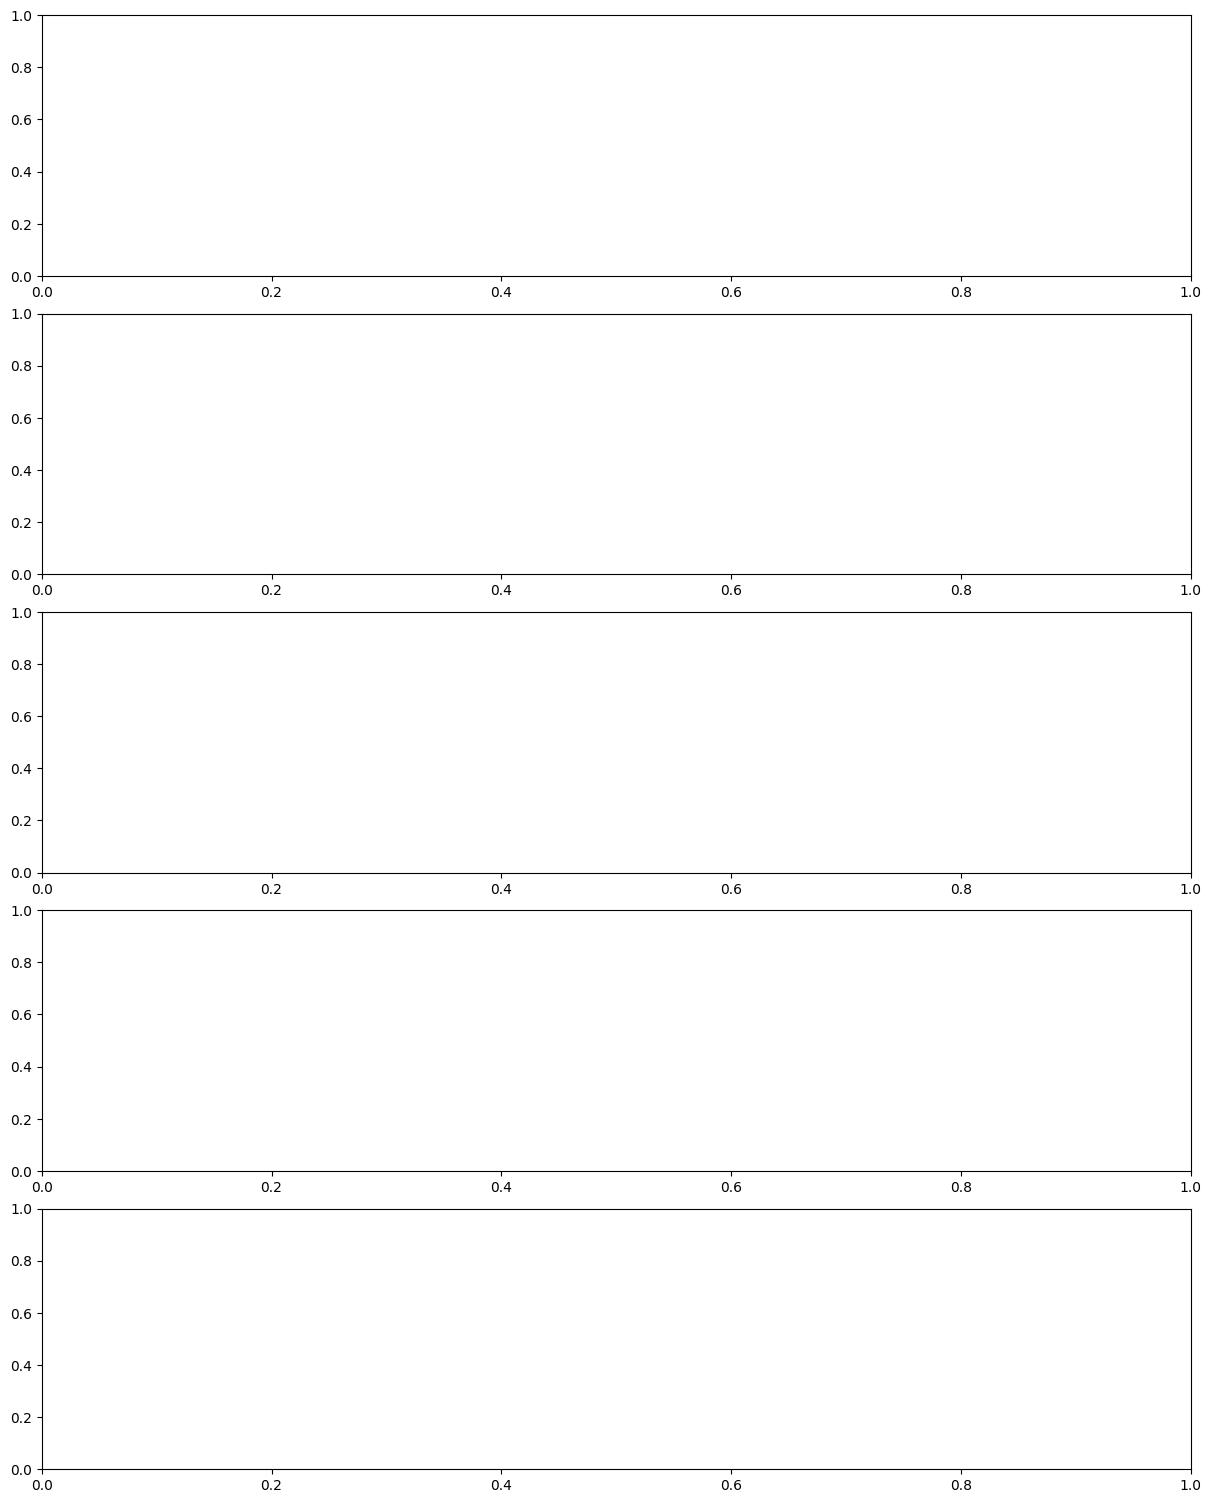

In [6]:
plot_group_spectrograms(group_a, normal_path, "Group A - Normal")